In [79]:
import math
import numpy as np
import matplotlib.pyplot as plt


def f_H(H, K1, K2, K3, H2CO3, Ksp, Kw):
    left = 2*(Ksp*H*H/(K1*K2*H2CO3)) + H
    right = (K2*H2CO3)/H + 2*(K2*K3*H2CO3)/(H*H) + Kw/H
    return left - right


def solve_pH_bisect(K1, K2, K3, H2CO3, Ksp, Kw=1e-14, pH_lo=4, pH_hi=10, tol=1e-12):
    # Solve in pH-space to avoid tiny H numbers
    def g(pH):
        H = 10**(-pH)
        return f_H(H, K1, K2, K3, H2CO3, Ksp, Kw)

    a, b = pH_lo, pH_hi
    fa, fb = g(a), g(b)

    if fb - fa > 0:
        raise ValueError("Root not bracketed; expand pH range.")

    for _ in range(200):
        m = 0.5*(a+b)
        fm = g(m)
        # print(m, fm)
        if abs(fm) < tol or (b-a) < 1e-10:
            return m
        if fa*fm <= 0:
            b, fb = m, fm
        else:
            a, fa = m, fm
    return 0.5*(a+b)


In [80]:
# Example constants
# Input condition: you will need to give the input parameter of K2, K3, H2CO3, Ksp, Kw
K1 = 10**(-1.47)
K2 = 10**(-6.35)
K3 = 10**(-10.33)
Ksp = 10**(-8.48)
Kw = 1e-14
pCO2 = 2.0
# pH = 6.0
pH_lo = 6.0
pH_hi = 6.0
H2CO3 = K1 * pCO2
pH = solve_pH_bisect(K1, K2, K3, H2CO3, Ksp, Kw, pH_lo, pH_hi)
print("pH =", pH)

pH = 6.0


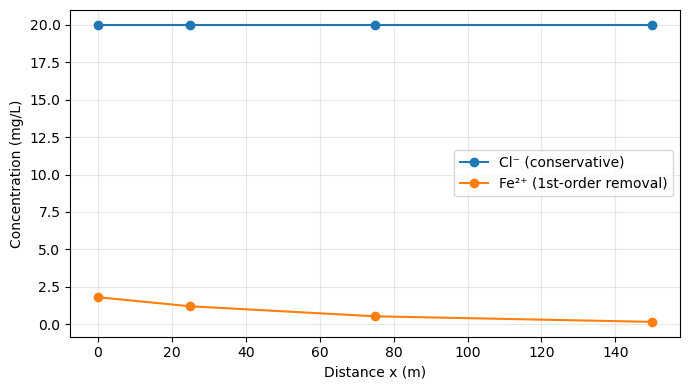

lambda (1/m) = 0.016397779494322272
L = 1/lambda (m) = 60.98386676965926


In [81]:
# given
v = 0.3
alpha = 1.0
D = alpha * v
k = 0.005
C0_cl = 20.0
C0_fe = 1.8

lam = (np.sqrt(v**2 + 4*k*D) - v) / (2*D)

x = np.array([0, 25, 75, 150], dtype=float)
Ccl = np.full_like(x, C0_cl)
Cfe = C0_fe * np.exp(-lam * x)

plt.figure(figsize=(7,4))
plt.plot(x, Ccl, marker="o", label="Cl⁻ (conservative)")
plt.plot(x, Cfe, marker="o", label="Fe²⁺ (1st-order removal)")
plt.xlabel("Distance x (m)")
plt.ylabel("Concentration (mg/L)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("lambda (1/m) =", lam)
print("L = 1/lambda (m) =", 1/lam)